
# Road Traffic Accident Severity Classification

This notebook shows a simple Machine Learning workflow using:
- Decision Tree
- Random Forest
- XGBoost


In [17]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


## 1. Data Collection

In [18]:

# Load Dataset
data = pd.read_csv("C:\\Users\\vhars\\Downloads\\RTA_Dataset.csv")

# Display first 5 rows
data.head()


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## 2. Data Preprocessing

In [19]:

# Dataset Information
print("Shape of dataset:", data.shape)

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())


Shape of dataset: (12316, 32)

Missing Values:
Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity

## 3. Data Cleaning

In [20]:

# Fill missing values with mode
for col in data.columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Remove duplicates
data.drop_duplicates(inplace=True)

print("Data cleaned successfully")


C:\Users\vhars\AppData\Local\Temp\ipykernel_18160\182326755.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
C:\Users\vhars\AppData\Local\Temp\ipykernel_18160\182326755.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

Data cleaned successfully


## 4. Data Transformation

In [21]:

# Convert categorical columns into numerical values
encoder = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = encoder.fit_transform(data[col])

data.head()


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,420,1,0,1,0,0,0,0,3,3,...,2,3,2,5,3,0,2,5,9,2
1,420,1,1,1,4,0,3,11,3,2,...,2,3,2,5,3,0,2,5,16,2
2,420,1,0,1,4,0,0,5,3,5,...,2,0,1,1,2,0,2,5,0,1
3,594,3,0,1,4,0,2,11,0,5,...,2,2,0,0,2,0,2,5,1,2
4,594,3,0,1,4,0,1,0,3,2,...,2,3,2,5,3,0,2,5,16,2


## 5. Exploratory Data Analysis (EDA)

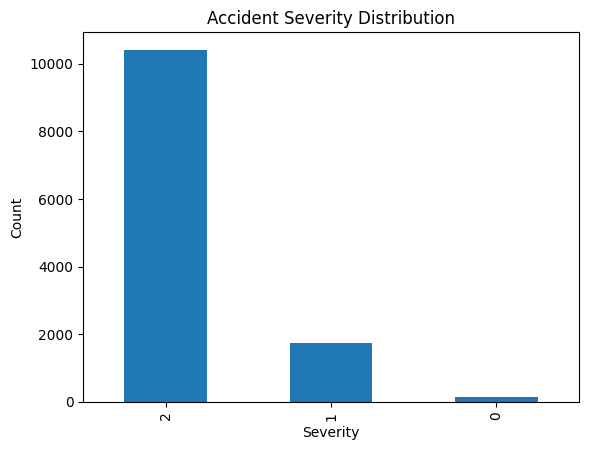

In [22]:

# Target variable distribution
data['Accident_severity'].value_counts().plot(kind='bar')

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()


## 6. Model Development

In [23]:

# Features and Target
X = data.drop('Accident_severity', axis=1)
y = data['Accident_severity']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (9852, 31)
Testing data shape: (2464, 31)


### Decision Tree

In [24]:

# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))


Decision Tree Accuracy:
0.7633928571428571

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.35      0.33        37
           1       0.27      0.29      0.28       363
           2       0.87      0.85      0.86      2064

    accuracy                           0.76      2464
   macro avg       0.48      0.50      0.49      2464
weighted avg       0.77      0.76      0.77      2464



### Random Forest

In [25]:

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy:
0.8405032467532467

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.82      0.02      0.05       363
           2       0.84      1.00      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.55      0.34      0.32      2464
weighted avg       0.82      0.84      0.77      2464



c:\Users\vhars\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vhars\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vhars\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### XGBoost

In [26]:

# XGBoost Model
xgb_model = XGBClassifier(eval_metric='mlogloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:")
print(accuracy_score(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy:
0.8506493506493507

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.22      0.35        37
           1       0.65      0.13      0.21       363
           2       0.86      0.99      0.92      2064

    accuracy                           0.85      2464
   macro avg       0.80      0.44      0.49      2464
weighted avg       0.83      0.85      0.81      2464



In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
y_pred = rf_model.predict(X_test) 

In [30]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.8405032467532467


In [31]:
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision Score:", precision)

Precision Score: 0.8246774755004473


c:\Users\vhars\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [32]:
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall Score:", recall)

Recall Score: 0.8405032467532467


In [33]:
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.7718721560413566


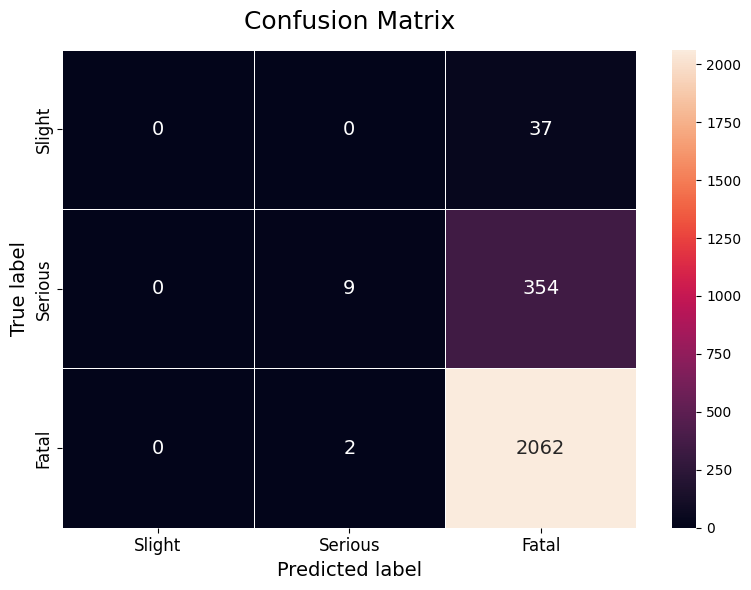

In [37]:
# Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Predict values
y_pred = rf_model.predict(X_test)   
# You can also use:
# dt_model.predict(X_test)
# xgb_model.predict(X_test)

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Class Labels
labels = ['Slight', 'Serious', 'Fatal']

# Plot Confusion Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,          # Show numbers
    fmt='d',             # Integer format
    cmap='rocket',       # Color style
    cbar=True,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size":14}
)

# Titles and Labels
plt.title("Confusion Matrix", fontsize=18, pad=15)

plt.xlabel("Predicted label", fontsize=14)
plt.ylabel("True label", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

# Show Plot
plt.show()

In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -0.16263955398896202


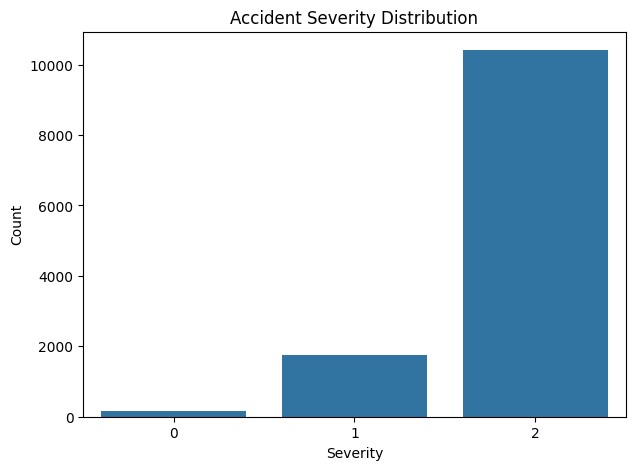

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.countplot(x='Accident_severity', data=data)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

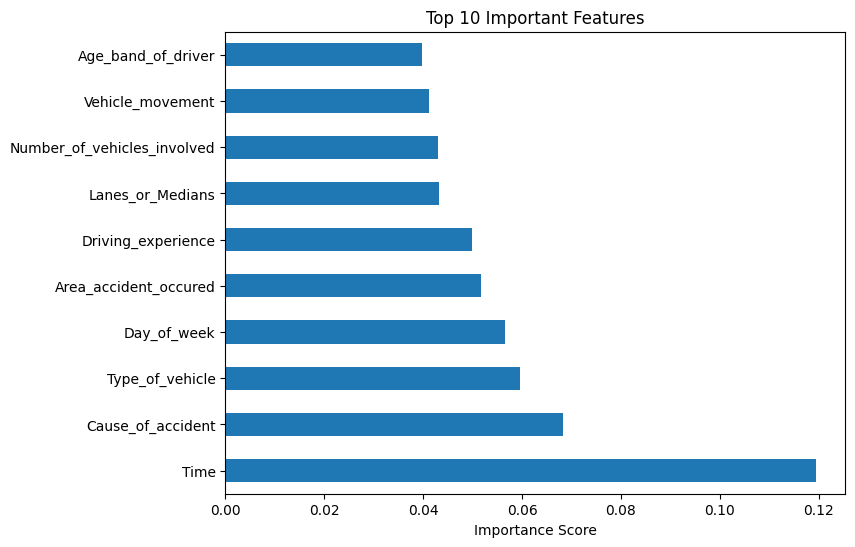

In [39]:
importance = rf_model.feature_importances_

feature_names = X.columns

feature_imp = pd.Series(importance, index=feature_names)

feature_imp.nlargest(10).plot(kind='barh', figsize=(8,6))

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.show()

In [40]:
models = ['Decision Tree', 'Random Forest', 'XGBoost']

accuracies = [dt_accuracy, rf_accuracy, xgb_accuracy]

plt.figure(figsize=(7,5))

sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

NameError: name 'dt_accuracy' is not defined

c:\Users\vhars\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


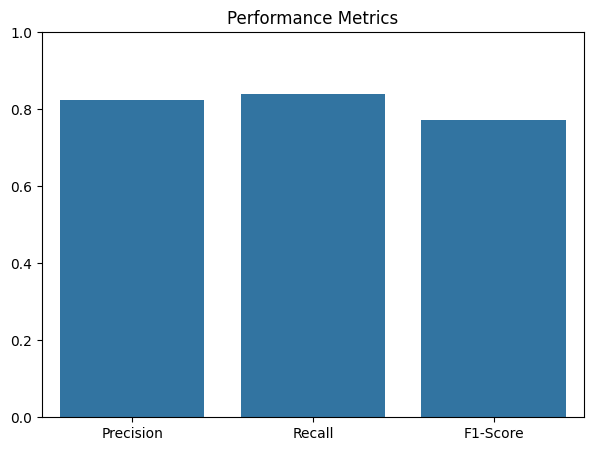

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Precision', 'Recall', 'F1-Score']
scores = [precision, recall, f1]

plt.figure(figsize=(7,5))

sns.barplot(x=metrics, y=scores)

plt.ylim(0,1)

plt.title("Performance Metrics")

plt.show()

In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Example for binary classification only

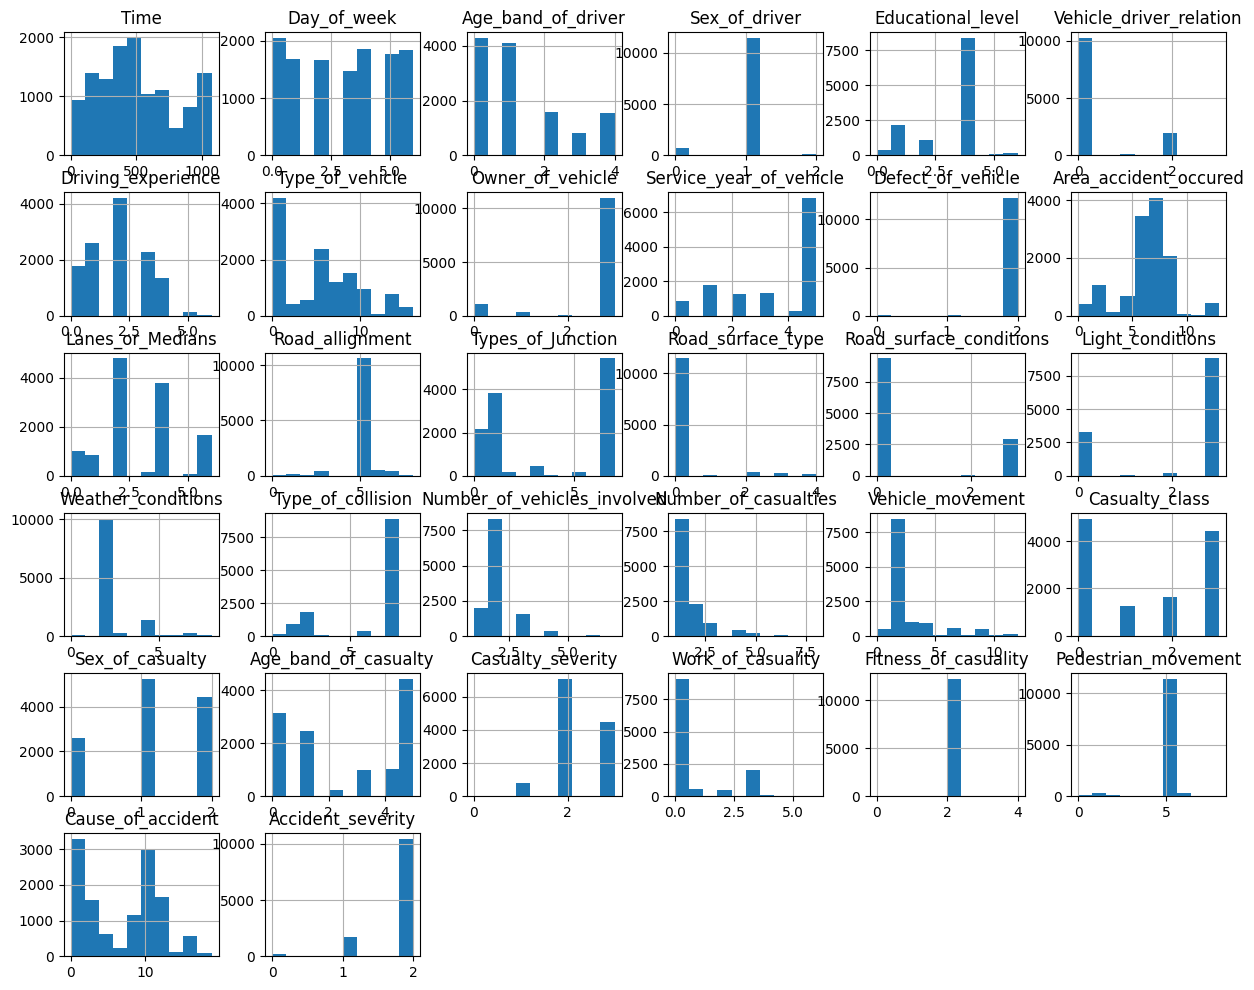

In [43]:
data.hist(figsize=(15,12))

plt.show()

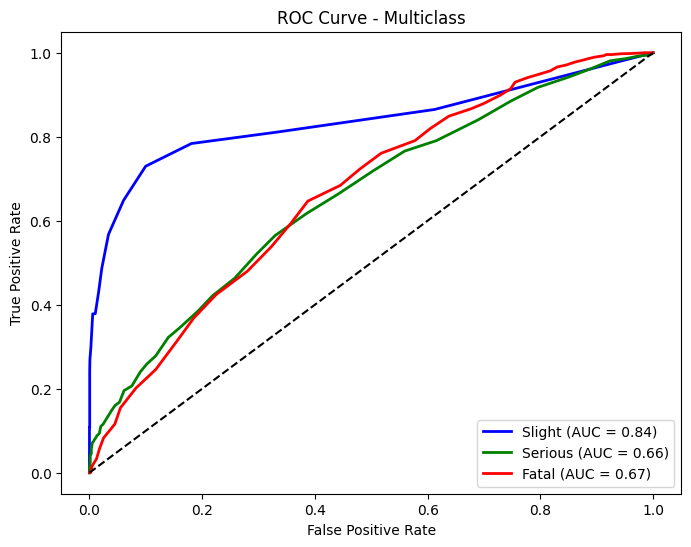

In [44]:
# Import Libraries
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

import matplotlib.pyplot as plt

# Binarize the output classes
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Predict probabilities
y_score = rf_model.predict_proba(X_test)

# Number of classes
n_classes = y_test_bin.shape[1]

# ROC Curve and AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curves
plt.figure(figsize=(8,6))

colors = ['blue', 'green', 'red']
labels = ['Slight', 'Serious', 'Fatal']

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        lw=2,
        label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})'
    )

# Random line
plt.plot([0,1], [0,1], 'k--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Multiclass")

plt.legend(loc="lower right")

plt.show()

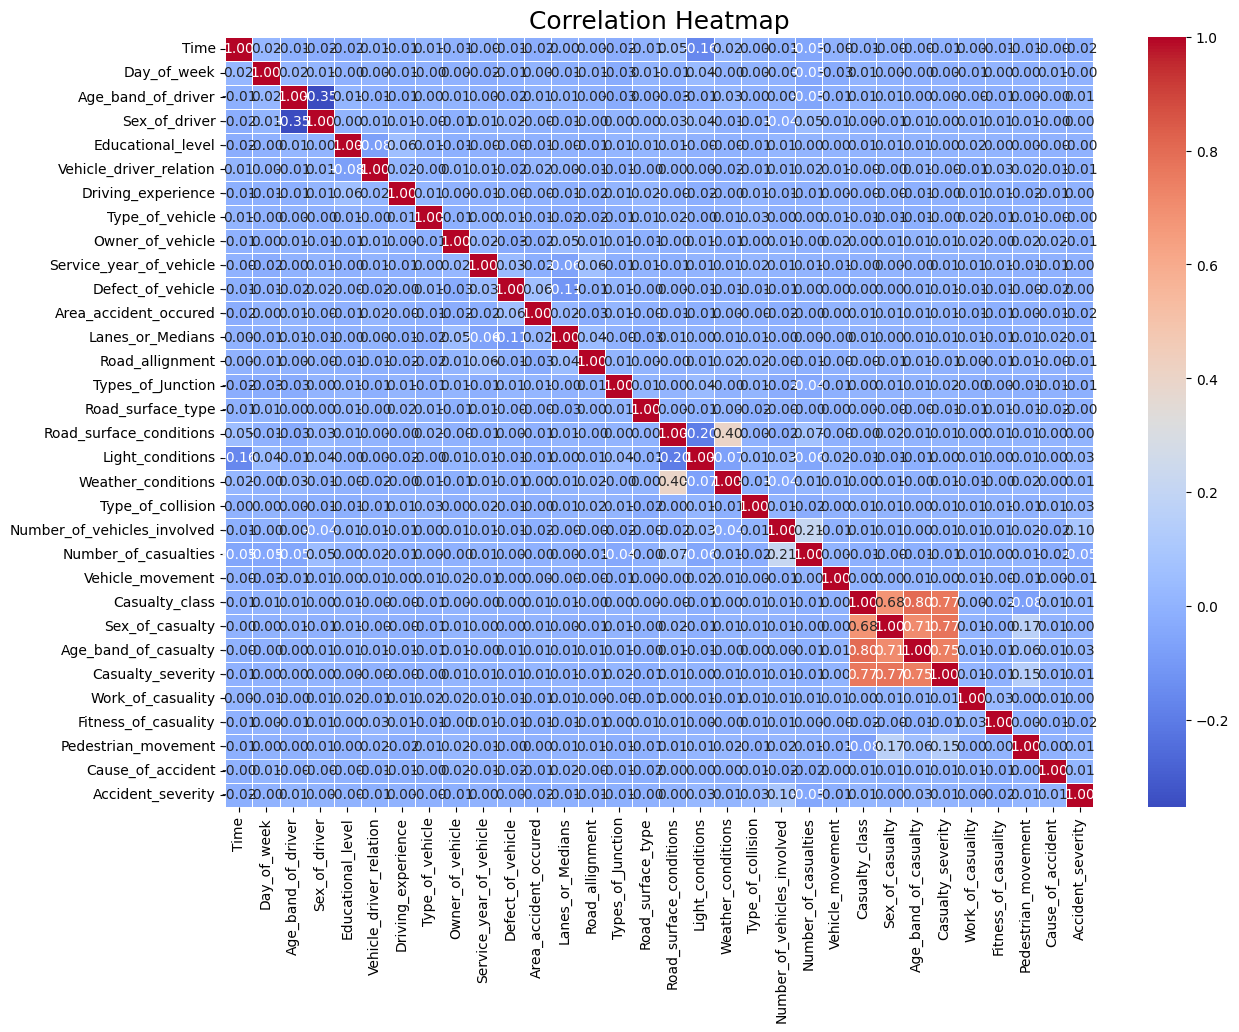

In [45]:
# Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Matrix
corr_matrix = data.corr()

# Plot Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show values
    cmap='coolwarm',     # Color style
    fmt='.2f',           # Decimal format
    linewidths=0.5
)

# Title
plt.title("Correlation Heatmap", fontsize=18)

# Show Plot
plt.show()


## 7. Model Deployment
The trained model can be used in real-world applications.

## 8. Maintenance
Regularly update the model with new data for better performance.
